In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Upload final cleaned sentiment dataset

from google.colab import files

uploaded = files.upload()

Saving final_sentiment_dataset.csv to final_sentiment_dataset.csv


In [3]:
# Load the dataset

import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset loaded successfully!")
print("File name:", file_name)
print("Dataset shape:", df.shape)

Dataset loaded successfully!
File name: final_sentiment_dataset.csv
Dataset shape: (5000, 4)


In [4]:
# Step 2: Validate the final sentiment dataset

print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate texts:", df['text'].duplicated().sum())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (5000, 4)

Missing values:
id           0
text         0
sentiment    0
domain       0
dtype: int64

Duplicate rows: 0

Duplicate texts: 0

Sentiment distribution:
sentiment
Positive    1672
Negative    1668
Neutral     1660
Name: count, dtype: int64

Columns:
['id', 'text', 'sentiment', 'domain']


In [5]:
# Step 3: Prepare X and y for Deep Learning

X = df['text']
y = df['sentiment']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 text samples:")
print(X.head())

print("\nFirst 5 labels:")
print(y.head())

X shape: (5000,)
y shape: (5000,)

First 5 text samples:
0    आज मागवलेल्या पुस्तकाची छपाई आणि बांधणी दोन्ही...
1    जेवणात मिठाचे प्रमाण इतके जास्त होते की चवच बि...
2    या चित्रपटाचा दुसरा भाग पुढील महिन्यात प्रदर्श...
3    उपचारानंतर माझी प्रकृती अपेक्षेपेक्षा लवकर सुध...
4    प्रयोगशाळेतील अनेक उपकरणे आज बंद असल्यामुळे सर...
Name: text, dtype: object

First 5 labels:
0    Positive
1    Negative
2     Neutral
3    Positive
4    Negative
Name: sentiment, dtype: object


In [6]:
# Step 4: Encode sentiment labels

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")

for label, encoded_value in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(label, "→", encoded_value)

print("\nFirst 10 encoded labels:")
print(y_encoded[:10])

Label mapping:
Negative → 0
Neutral → 1
Positive → 2

First 10 encoded labels:
[2 0 1 2 0 1 2 0 1 2]


In [7]:
# Step 5: Train, Validation, Test Split

from sklearn.model_selection import train_test_split

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Second split: 90% training, 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.10,
    random_state=42,
    stratify=y_train_val
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 3600
Validation samples: 400
Testing samples: 1000


In [8]:
print("\nTraining distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTesting distribution:")
print(pd.Series(y_test).value_counts().sort_index())


Training distribution:
0    1201
1    1195
2    1204
Name: count, dtype: int64

Validation distribution:
0    133
1    133
2    134
Name: count, dtype: int64

Testing distribution:
0    334
1    332
2    334
Name: count, dtype: int64


In [9]:
# Step 6: Tokenization

from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Tokenization completed successfully!")

print("\nVocabulary size:", len(tokenizer.word_index))

print("\nFirst training sequence:")
print(X_train_seq[0])

Tokenization completed successfully!

Vocabulary size: 2763

First training sequence:
[124, 11, 282, 38, 61, 132, 145]


In [11]:
# Step 7: Analyze sequence lengths

train_lengths = [len(seq) for seq in X_train_seq]

print("Sequence length statistics:")
print(pd.Series(train_lengths).describe())

Sequence length statistics:
count    3600.000000
mean        7.699444
std         1.651727
min         4.000000
25%         7.000000
50%         8.000000
75%         9.000000
max        14.000000
dtype: float64


In [12]:
# Check useful percentiles

for percentile in [90, 95, 99, 100]:
    print(
        f"{percentile}th percentile:",
        int(np.percentile(train_lengths, percentile))
    )

90th percentile: 10
95th percentile: 11
99th percentile: 12
100th percentile: 14


In [13]:
# Step 8: Padding sequences

from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 14

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print("Training padded shape:", X_train_pad.shape)
print("Validation padded shape:", X_val_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

print("\nFirst padded training sequence:")
print(X_train_pad[0])

Training padded shape: (3600, 14)
Validation padded shape: (400, 14)
Testing padded shape: (1000, 14)

First padded training sequence:
[124  11 282  38  61 132 145   0   0   0   0   0   0   0]


In [14]:
# Step 9: One-hot encode labels

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print("Training labels shape:", y_train_cat.shape)
print("Validation labels shape:", y_val_cat.shape)
print("Testing labels shape:", y_test_cat.shape)

print("\nFirst 5 training labels:")
print(y_train_cat[:5])

Training labels shape: (3600, 3)
Validation labels shape: (400, 3)
Testing labels shape: (1000, 3)

First 5 training labels:
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


In [15]:
# Step 10: Common Deep Learning configuration

VOCAB_SIZE = 10000
MAX_LEN = 14
EMBEDDING_DIM = 128
NUM_CLASSES = 3

print("DL configuration:")
print("Vocabulary size :", VOCAB_SIZE)
print("Maximum length  :", MAX_LEN)
print("Embedding dim   :", EMBEDDING_DIM)
print("Number of classes:", NUM_CLASSES)

DL configuration:
Vocabulary size : 10000
Maximum length  : 14
Embedding dim   : 128
Number of classes: 3


In [17]:
# Step 11: Build RNN model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

rnn_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    SimpleRNN(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,531 (4.94 MB)

 Trainable params: 1,294,531 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Step 12: Train RNN

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.8133 - loss: 0.4540 - val_accuracy: 0.9275 - val_loss: 0.2023
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9819 - loss: 0.0514 - val_accuracy: 0.9300 - val_loss: 0.2012
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9969 - loss: 0.0102 - val_accuracy: 0.9400 - val_loss: 0.1934
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9989 - loss: 0.0065 - val_accuracy: 0.9325 - val_loss: 0.2360
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9986 - loss: 0.0054 - val_accuracy: 0.9275 - val_loss: 0.2606
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9994 - loss: 0.0016 - val_accuracy: 0.9300 - val_loss: 0.2624


In [19]:
# Step 13: Evaluate RNN on test data

rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("RNN Test Loss:", round(rnn_test_loss, 4))
print("RNN Test Accuracy:", round(rnn_test_accuracy, 4))

RNN Test Loss: 0.1727
RNN Test Accuracy: 0.943


In [20]:
# RNN predictions

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_rnn_prob = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn = np.argmax(y_pred_rnn_prob, axis=1)

rnn_accuracy = accuracy_score(y_test, y_pred_rnn)
rnn_precision = precision_score(
    y_test, y_pred_rnn, average='weighted'
)
rnn_recall = recall_score(
    y_test, y_pred_rnn, average='weighted'
)
rnn_f1 = f1_score(
    y_test, y_pred_rnn, average='weighted'
)

print("\nRNN Results")
print("-----------")
print("Accuracy :", round(rnn_accuracy, 4))
print("Precision:", round(rnn_precision, 4))
print("Recall   :", round(rnn_recall, 4))
print("F1-score :", round(rnn_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rnn,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rnn))


RNN Results
-----------
Accuracy : 0.943
Precision: 0.9429
Recall   : 0.943
F1-score : 0.9429

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.92      0.92       334
     Neutral       0.96      0.98      0.97       332
    Positive       0.94      0.93      0.94       334

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000


Confusion Matrix:
[[307   8  19]
 [  6 324   2]
 [ 17   5 312]]


In [21]:
# Step 14: Store RNN results

dl_results = []

dl_results.append({
    'Model': 'RNN',
    'Accuracy': rnn_accuracy,
    'Precision': rnn_precision,
    'Recall': rnn_recall,
    'F1-Score': rnn_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.943,0.942851,0.943,0.942896


In [22]:
# Step 15: Build LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

lstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,587 (5.08 MB)

 Trainable params: 1,331,587 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Step 16: Train LSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_lstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_lstm],
    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.7764 - loss: 0.5015 - val_accuracy: 0.9625 - val_loss: 0.1112
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9867 - loss: 0.0479 - val_accuracy: 0.9625 - val_loss: 0.1212
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9969 - loss: 0.0113 - val_accuracy: 0.9775 - val_loss: 0.0774
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9981 - loss: 0.0043 - val_accuracy: 0.9650 - val_loss: 0.1197
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.9725 - val_loss: 0.1070
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9992 - loss: 0.0020 - val_accuracy: 0.9625 - val_loss: 0.1326


In [24]:
# Step 17: Evaluate LSTM on test data

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("LSTM Test Loss:", round(lstm_test_loss, 4))
print("LSTM Test Accuracy:", round(lstm_test_accuracy, 4))

LSTM Test Loss: 0.1071
LSTM Test Accuracy: 0.969


In [25]:
# LSTM predictions and detailed metrics

y_pred_lstm_prob = lstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_lstm = np.argmax(
    y_pred_lstm_prob,
    axis=1
)

lstm_accuracy = accuracy_score(
    y_test,
    y_pred_lstm
)

lstm_precision = precision_score(
    y_test,
    y_pred_lstm,
    average='weighted'
)

lstm_recall = recall_score(
    y_test,
    y_pred_lstm,
    average='weighted'
)

lstm_f1 = f1_score(
    y_test,
    y_pred_lstm,
    average='weighted'
)

print("\nLSTM Results")
print("------------")
print("Accuracy :", round(lstm_accuracy, 4))
print("Precision:", round(lstm_precision, 4))
print("Recall   :", round(lstm_recall, 4))
print("F1-score :", round(lstm_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lstm,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_lstm
    )
)


LSTM Results
------------
Accuracy : 0.969
Precision: 0.9692
Recall   : 0.969
F1-score : 0.969

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.98      0.97       334
     Neutral       0.97      0.98      0.97       332
    Positive       0.98      0.95      0.96       334

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000


Confusion Matrix:
[[326   5   3]
 [  3 326   3]
 [ 11   6 317]]


In [26]:
# Step 18: Store LSTM results

dl_results.append({
    'Model': 'LSTM',
    'Accuracy': lstm_accuracy,
    'Precision': lstm_precision,
    'Recall': lstm_recall,
    'F1-Score': lstm_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.943,0.942851,0.943,0.942896
1,LSTM,0.969,0.969206,0.969,0.968969


In [27]:
# Step 19: Build BiLSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout
)

bilstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,383,043 (5.28 MB)

 Trainable params: 1,383,043 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Step 20: Train BiLSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_bilstm],
    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7672 - loss: 0.5329 - val_accuracy: 0.9525 - val_loss: 0.1227
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9839 - loss: 0.0504 - val_accuracy: 0.9725 - val_loss: 0.0812
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9983 - loss: 0.0055 - val_accuracy: 0.9700 - val_loss: 0.1029
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 1.0000 - loss: 3.7935e-04 - val_accuracy: 0.9675 - val_loss: 0.1152
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 1.0000 - loss: 1.4049e-04 - val_accuracy: 0.9675 - val_loss: 0.1242


In [29]:
# Step 21: Evaluate BiLSTM on test data

bilstm_test_loss, bilstm_test_accuracy = bilstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("BiLSTM Test Loss:", round(bilstm_test_loss, 4))
print("BiLSTM Test Accuracy:", round(bilstm_test_accuracy, 4))

BiLSTM Test Loss: 0.0889
BiLSTM Test Accuracy: 0.973


In [30]:
# BiLSTM predictions and detailed metrics

y_pred_bilstm_prob = bilstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_bilstm = np.argmax(
    y_pred_bilstm_prob,
    axis=1
)

bilstm_accuracy = accuracy_score(
    y_test,
    y_pred_bilstm
)

bilstm_precision = precision_score(
    y_test,
    y_pred_bilstm,
    average='weighted'
)

bilstm_recall = recall_score(
    y_test,
    y_pred_bilstm,
    average='weighted'
)

bilstm_f1 = f1_score(
    y_test,
    y_pred_bilstm,
    average='weighted'
)

print("\nBiLSTM Results")
print("--------------")
print("Accuracy :", round(bilstm_accuracy, 4))
print("Precision:", round(bilstm_precision, 4))
print("Recall   :", round(bilstm_recall, 4))
print("F1-score :", round(bilstm_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_bilstm,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_bilstm
    )
)


BiLSTM Results
--------------
Accuracy : 0.973
Precision: 0.9732
Recall   : 0.973
F1-score : 0.973

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97       334
     Neutral       0.96      0.99      0.97       332
    Positive       0.98      0.96      0.97       334

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000


Confusion Matrix:
[[323   5   6]
 [  2 329   1]
 [  4   9 321]]


In [31]:
# Step 22: Store BiLSTM results

dl_results.append({
    'Model': 'BiLSTM',
    'Accuracy': bilstm_accuracy,
    'Precision': bilstm_precision,
    'Recall': bilstm_recall,
    'F1-Score': bilstm_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.943,0.942851,0.943,0.942896
1,LSTM,0.969,0.969206,0.969,0.968969
2,BiLSTM,0.973,0.973230,0.973,0.972984


In [32]:
# Step 23: Build CNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

cnn_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    ),

    GlobalMaxPooling1D(),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 12, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,333,507 (5.09 MB)

 Trainable params: 1,333,507 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Step 24: Train CNN

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cnn = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_cnn],
    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8203 - loss: 0.5635 - val_accuracy: 0.9700 - val_loss: 0.0947
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9817 - loss: 0.0585 - val_accuracy: 0.9775 - val_loss: 0.0643
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9994 - loss: 0.0067 - val_accuracy: 0.9775 - val_loss: 0.0537
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9997 - loss: 0.0023 - val_accuracy: 0.9750 - val_loss: 0.0535
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9775 - val_loss: 0.0521
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 6.0942e-04 - val_accuracy: 0.9800 - val_loss: 0.0531
Epoch 7/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 4.0950e-04 - val_accuracy: 0.9825 - val_loss: 0.0541
Epoch 8/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 1.0000 - loss: 3.7344e-0

In [34]:
# Step 25: Evaluate CNN on test data

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("CNN Test Loss:", round(cnn_test_loss, 4))
print("CNN Test Accuracy:", round(cnn_test_accuracy, 4))

CNN Test Loss: 0.0619
CNN Test Accuracy: 0.978


In [35]:
# CNN predictions and detailed metrics

y_pred_cnn_prob = cnn_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_cnn = np.argmax(
    y_pred_cnn_prob,
    axis=1
)

cnn_accuracy = accuracy_score(
    y_test,
    y_pred_cnn
)

cnn_precision = precision_score(
    y_test,
    y_pred_cnn,
    average='weighted'
)

cnn_recall = recall_score(
    y_test,
    y_pred_cnn,
    average='weighted'
)

cnn_f1 = f1_score(
    y_test,
    y_pred_cnn,
    average='weighted'
)

print("\nCNN Results")
print("-----------")
print("Accuracy :", round(cnn_accuracy, 4))
print("Precision:", round(cnn_precision, 4))
print("Recall   :", round(cnn_recall, 4))
print("F1-score :", round(cnn_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_cnn,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_cnn
    )
)


CNN Results
-----------
Accuracy : 0.978
Precision: 0.978
Recall   : 0.978
F1-score : 0.978

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.98      0.98       334
     Neutral       0.97      0.98      0.98       332
    Positive       0.98      0.97      0.98       334

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Confusion Matrix:
[[327   3   4]
 [  3 327   2]
 [  4   6 324]]


In [36]:
# Step 26: Store CNN results

dl_results.append({
    'Model': 'CNN',
    'Accuracy': cnn_accuracy,
    'Precision': cnn_precision,
    'Recall': cnn_recall,
    'F1-Score': cnn_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.943,0.942851,0.943,0.942896
1,LSTM,0.969,0.969206,0.969,0.968969
2,BiLSTM,0.973,0.973230,0.973,0.972984
3,CNN,0.978,0.978034,0.978,0.977994


In [37]:
# Step 27: Build GRU model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GRU,
    Dense,
    Dropout
)

gru_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    GRU(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,427 (5.03 MB)

 Trainable params: 1,319,427 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Step 28: Train GRU

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_gru = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

gru_history = gru_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_gru],
    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.6342 - loss: 0.7326 - val_accuracy: 0.9575 - val_loss: 0.1342
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9811 - loss: 0.0658 - val_accuracy: 0.9675 - val_loss: 0.0819
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9975 - loss: 0.0107 - val_accuracy: 0.9700 - val_loss: 0.0979
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9992 - loss: 0.0030 - val_accuracy: 0.9600 - val_loss: 0.1545
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9981 - loss: 0.0063 - val_accuracy: 0.9725 - val_loss: 0.1006


In [39]:
# Step 29: Evaluate GRU on test data

gru_test_loss, gru_test_accuracy = gru_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("GRU Test Loss:", round(gru_test_loss, 4))
print("GRU Test Accuracy:", round(gru_test_accuracy, 4))

GRU Test Loss: 0.0954
GRU Test Accuracy: 0.969


In [40]:
# GRU predictions and detailed metrics

y_pred_gru_prob = gru_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_gru = np.argmax(
    y_pred_gru_prob,
    axis=1
)

gru_accuracy = accuracy_score(
    y_test,
    y_pred_gru
)

gru_precision = precision_score(
    y_test,
    y_pred_gru,
    average='weighted'
)

gru_recall = recall_score(
    y_test,
    y_pred_gru,
    average='weighted'
)

gru_f1 = f1_score(
    y_test,
    y_pred_gru,
    average='weighted'
)

print("\nGRU Results")
print("-----------")
print("Accuracy :", round(gru_accuracy, 4))
print("Precision:", round(gru_precision, 4))
print("Recall   :", round(gru_recall, 4))
print("F1-score :", round(gru_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_gru,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_gru
    )
)


GRU Results
-----------
Accuracy : 0.969
Precision: 0.9693
Recall   : 0.969
F1-score : 0.969

Classification Report:
              precision    recall  f1-score   support

    Negative       0.99      0.96      0.97       334
     Neutral       0.96      0.98      0.97       332
    Positive       0.96      0.97      0.96       334

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000


Confusion Matrix:
[[319   4  11]
 [  3 327   2]
 [  1  10 323]]


In [41]:
# Step 30: Store GRU results

dl_results.append({
    'Model': 'GRU',
    'Accuracy': gru_accuracy,
    'Precision': gru_precision,
    'Recall': gru_recall,
    'F1-Score': gru_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.943,0.942851,0.943,0.942896
1,LSTM,0.969,0.969206,0.969,0.968969
2,BiLSTM,0.973,0.973230,0.973,0.972984
3,CNN,0.978,0.978034,0.978,0.977994
4,GRU,0.969,0.969311,0.969,0.969004


In [42]:
# Step 31: Build CNN-BiLSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    Bidirectional,
    LSTM,
    Dropout,
    Dense
)

cnn_bilstm_model = Sequential([
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation='relu'
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(NUM_CLASSES, activation='softmax')
])

cnn_bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_bilstm_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 14, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,432,323 (5.46 MB)

 Trainable params: 1,432,323 (5.46 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Step 32: Train CNN-BiLSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_cnn_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_bilstm_history = cnn_bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_cnn_bilstm],
    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.8067 - loss: 0.4418 - val_accuracy: 0.9625 - val_loss: 0.0973
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9600 - val_loss: 0.1258
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9989 - loss: 0.0050 - val_accuracy: 0.9550 - val_loss: 0.1399
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 1.0000 - loss: 4.9818e-04 - val_accuracy: 0.9550 - val_loss: 0.1655


In [44]:
# Step 33: Evaluate CNN-BiLSTM on test data

cnn_bilstm_test_loss, cnn_bilstm_test_accuracy = cnn_bilstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("CNN-BiLSTM Test Loss:", round(cnn_bilstm_test_loss, 4))
print("CNN-BiLSTM Test Accuracy:", round(cnn_bilstm_test_accuracy, 4))

CNN-BiLSTM Test Loss: 0.0785
CNN-BiLSTM Test Accuracy: 0.969


In [45]:
# CNN-BiLSTM predictions and detailed metrics

y_pred_cnn_bilstm_prob = cnn_bilstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_cnn_bilstm = np.argmax(
    y_pred_cnn_bilstm_prob,
    axis=1
)

cnn_bilstm_accuracy = accuracy_score(
    y_test,
    y_pred_cnn_bilstm
)

cnn_bilstm_precision = precision_score(
    y_test,
    y_pred_cnn_bilstm,
    average='weighted'
)

cnn_bilstm_recall = recall_score(
    y_test,
    y_pred_cnn_bilstm,
    average='weighted'
)

cnn_bilstm_f1 = f1_score(
    y_test,
    y_pred_cnn_bilstm,
    average='weighted'
)

print("\nCNN-BiLSTM Results")
print("------------------")
print("Accuracy :", round(cnn_bilstm_accuracy, 4))
print("Precision:", round(cnn_bilstm_precision, 4))
print("Recall   :", round(cnn_bilstm_recall, 4))
print("F1-score :", round(cnn_bilstm_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_cnn_bilstm,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_cnn_bilstm
    )
)


CNN-BiLSTM Results
------------------
Accuracy : 0.969
Precision: 0.9691
Recall   : 0.969
F1-score : 0.969

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.97      0.96       334
     Neutral       0.98      0.97      0.97       332
    Positive       0.97      0.97      0.97       334

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000


Confusion Matrix:
[[323   3   8]
 [  9 321   2]
 [  5   4 325]]


In [46]:
# Step 34: Store CNN-BiLSTM results

dl_results.append({
    'Model': 'CNN-BiLSTM',
    'Accuracy': cnn_bilstm_accuracy,
    'Precision': cnn_bilstm_precision,
    'Recall': cnn_bilstm_recall,
    'F1-Score': cnn_bilstm_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.943,0.942851,0.943,0.942896
1,LSTM,0.969,0.969206,0.969,0.968969
2,BiLSTM,0.973,0.973230,0.973,0.972984
3,CNN,0.978,0.978034,0.978,0.977994
4,GRU,0.969,0.969311,0.969,0.969004
5,CNN-BiLSTM,0.969,0.969069,0.969,0.969016


In [47]:
# Step 35: Build Attention-BiLSTM model

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Attention,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

# Input
attention_input = Input(shape=(MAX_LEN,))

# Embedding
attention_embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)(attention_input)

# BiLSTM must return sequences for attention
attention_bilstm_output = Bidirectional(
    LSTM(64, return_sequences=True)
)(attention_embedding)

# Self-attention
attention_output = Attention()([
    attention_bilstm_output,
    attention_bilstm_output
])

# Pool the attended sequence
attention_pooled = GlobalAveragePooling1D()(attention_output)

# Classification layers
attention_dropout = Dropout(0.3)(attention_pooled)

attention_dense = Dense(
    32,
    activation='relu'
)(attention_dropout)

attention_output_final = Dense(
    NUM_CLASSES,
    activation='softmax'
)(attention_dense)

# Build model
attention_bilstm_model = Model(
    inputs=attention_input,
    outputs=attention_output_final
)

attention_bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

attention_bilstm_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 14, 128)   │  1,280,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 14, 128)   │     98,816 │ embedding_7[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 14, 128)   │          0 │ bidirectional_2[… │
│ (Attention)         │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      4,128 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 3)         │         99 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,383,043 (5.28 MB)

 Trainable params: 1,383,043 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Step 36: Train Attention-BiLSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_attention = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

attention_bilstm_history = attention_bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_attention],
    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.7764 - loss: 0.5024 - val_accuracy: 0.9475 - val_loss: 0.1473
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9856 - loss: 0.0457 - val_accuracy: 0.9450 - val_loss: 0.1471
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9981 - loss: 0.0094 - val_accuracy: 0.9425 - val_loss: 0.2101
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9989 - loss: 0.0049 - val_accuracy: 0.9625 - val_loss: 0.1423
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9975 - loss: 0.0085 - val_accuracy: 0.9575 - val_loss: 0.1247
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9525 - val_loss: 0.1572
Epoch 7/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9997 - loss: 6.4906e-04 - val_accuracy: 0.9575 - val_loss: 0.1564
Epoch 8/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 1.0000 - loss: 1.2912e-04 -

In [49]:
# Step 37: Evaluate Attention-BiLSTM

attention_test_loss, attention_test_accuracy = attention_bilstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Attention-BiLSTM Test Loss:", round(attention_test_loss, 4))
print("Attention-BiLSTM Test Accuracy:", round(attention_test_accuracy, 4))

Attention-BiLSTM Test Loss: 0.1242
Attention-BiLSTM Test Accuracy: 0.961


In [50]:
# Attention-BiLSTM predictions and detailed metrics

y_pred_attention_prob = attention_bilstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_attention = np.argmax(
    y_pred_attention_prob,
    axis=1
)

attention_accuracy = accuracy_score(
    y_test,
    y_pred_attention
)

attention_precision = precision_score(
    y_test,
    y_pred_attention,
    average='weighted'
)

attention_recall = recall_score(
    y_test,
    y_pred_attention,
    average='weighted'
)

attention_f1 = f1_score(
    y_test,
    y_pred_attention,
    average='weighted'
)

print("\nAttention-BiLSTM Results")
print("------------------------")
print("Accuracy :", round(attention_accuracy, 4))
print("Precision:", round(attention_precision, 4))
print("Recall   :", round(attention_recall, 4))
print("F1-score :", round(attention_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_attention,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_attention
    )
)


Attention-BiLSTM Results
------------------------
Accuracy : 0.961
Precision: 0.9613
Recall   : 0.961
F1-score : 0.961

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95       334
     Neutral       0.98      0.97      0.98       332
    Positive       0.96      0.95      0.95       334

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000


Confusion Matrix:
[[322   2  10]
 [  7 323   2]
 [ 14   4 316]]


In [51]:
# Step 38: Store Attention-BiLSTM results

dl_results.append({
    'Model': 'Attention-BiLSTM',
    'Accuracy': attention_accuracy,
    'Precision': attention_precision,
    'Recall': attention_recall,
    'F1-Score': attention_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,RNN,0.943,0.942851,0.943,0.942896
1,LSTM,0.969,0.969206,0.969,0.968969
2,BiLSTM,0.973,0.973230,0.973,0.972984
3,CNN,0.978,0.978034,0.978,0.977994
4,GRU,0.969,0.969311,0.969,0.969004
5,CNN-BiLSTM,0.969,0.969069,0.969,0.969016
6,Attention-BiLSTM,0.961,0.961277,0.961,0.961049


In [52]:
# Improved Parallel CNN + BiLSTM

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate
)

hybrid_input = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)(hybrid_input)

# CNN branch
cnn_branch = Conv1D(
    filters=128,
    kernel_size=3,
    activation='relu'
)(embedding)

cnn_branch = GlobalMaxPooling1D()(cnn_branch)

# BiLSTM branch
bilstm_branch = Bidirectional(
    LSTM(64)
)(embedding)

# Combine both representations
combined = Concatenate()([
    cnn_branch,
    bilstm_branch
])

combined = Dropout(0.3)(combined)

combined = Dense(
    64,
    activation='relu'
)(combined)

combined = Dropout(0.2)(combined)

output = Dense(
    NUM_CLASSES,
    activation='softmax'
)(combined)

hybrid_cnn_bilstm_model = Model(
    inputs=hybrid_input,
    outputs=output
)

hybrid_cnn_bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_cnn_bilstm_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 14, 128)   │  1,280,000 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 12, 128)   │     49,280 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │     98,816 │ embedding_8[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │     16,448 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 3)         │        195 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,444,739 (5.51 MB)

 Trainable params: 1,444,739 (5.51 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Step 39: Train Parallel CNN + BiLSTM

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_hybrid = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

hybrid_history = hybrid_cnn_bilstm_model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_hybrid],
    verbose=1
)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.7931 - loss: 0.5449 - val_accuracy: 0.9525 - val_loss: 0.1279
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9847 - loss: 0.0437 - val_accuracy: 0.9725 - val_loss: 0.0734
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.9775 - val_loss: 0.0715
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9750 - val_loss: 0.0735
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 1.0000 - loss: 3.6321e-04 - val_accuracy: 0.9750 - val_loss: 0.0765
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 1.0000 - loss: 1.8996e-04 - val_accuracy: 0.9750 - val_loss: 0.0801


In [54]:
# Step 40: Evaluate Parallel CNN + BiLSTM

hybrid_test_loss, hybrid_test_accuracy = hybrid_cnn_bilstm_model.evaluate(
    X_test_pad,
    y_test_cat,
    verbose=0
)

print("Hybrid Test Loss:", round(hybrid_test_loss, 4))
print("Hybrid Test Accuracy:", round(hybrid_test_accuracy, 4))

Hybrid Test Loss: 0.0824
Hybrid Test Accuracy: 0.971


In [55]:
# Hybrid predictions and detailed metrics

y_pred_hybrid_prob = hybrid_cnn_bilstm_model.predict(
    X_test_pad,
    verbose=0
)

y_pred_hybrid = np.argmax(
    y_pred_hybrid_prob,
    axis=1
)

hybrid_accuracy = accuracy_score(
    y_test,
    y_pred_hybrid
)

hybrid_precision = precision_score(
    y_test,
    y_pred_hybrid,
    average='weighted'
)

hybrid_recall = recall_score(
    y_test,
    y_pred_hybrid,
    average='weighted'
)

hybrid_f1 = f1_score(
    y_test,
    y_pred_hybrid,
    average='weighted'
)

print("\nParallel CNN-BiLSTM Results")
print("---------------------------")
print("Accuracy :", round(hybrid_accuracy, 4))
print("Precision:", round(hybrid_precision, 4))
print("Recall   :", round(hybrid_recall, 4))
print("F1-score :", round(hybrid_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_hybrid,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_hybrid
    )
)


Parallel CNN-BiLSTM Results
---------------------------
Accuracy : 0.971
Precision: 0.9712
Recall   : 0.971
F1-score : 0.971

Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97       334
     Neutral       0.96      0.98      0.97       332
    Positive       0.98      0.96      0.97       334

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000


Confusion Matrix:
[[324   6   4]
 [  3 327   2]
 [  6   8 320]]


In [56]:
# Step 41: Store Parallel CNN-BiLSTM results

dl_results.append({
    'Model': 'Parallel CNN-BiLSTM',
    'Accuracy': hybrid_accuracy,
    'Precision': hybrid_precision,
    'Recall': hybrid_recall,
    'F1-Score': hybrid_f1
})

dl_results_df = pd.DataFrame(dl_results)

display(
    dl_results_df.sort_values(
        by='F1-Score',
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.978,0.978034,0.978,0.977994
1,BiLSTM,0.973,0.973230,0.973,0.972984
2,Parallel CNN-BiLSTM,0.971,0.971195,0.971,0.970992
3,CNN-BiLSTM,0.969,0.969069,0.969,0.969016
4,GRU,0.969,0.969311,0.969,0.969004
5,LSTM,0.969,0.969206,0.969,0.968969
6,Attention-BiLSTM,0.961,0.961277,0.961,0.961049
7,RNN,0.943,0.942851,0.943,0.942896


In [57]:
# Step 42: Save Sentiment DL comparison

dl_results_df = dl_results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

dl_results_df.to_csv(
    'sentiment_dl_model_comparison.csv',
    index=False
)

print("Sentiment DL comparison saved successfully!")
display(dl_results_df)

Sentiment DL comparison saved successfully!


,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.978,0.978034,0.978,0.977994
1,BiLSTM,0.973,0.973230,0.973,0.972984
2,Parallel CNN-BiLSTM,0.971,0.971195,0.971,0.970992
3,CNN-BiLSTM,0.969,0.969069,0.969,0.969016
4,GRU,0.969,0.969311,0.969,0.969004
5,LSTM,0.969,0.969206,0.969,0.968969
6,Attention-BiLSTM,0.961,0.961277,0.961,0.961049
7,RNN,0.943,0.942851,0.943,0.942896


In [59]:
# Step 41: Add Parallel CNN-BiLSTM result

dl_results.append({
    'Model': 'Parallel CNN-BiLSTM',
    'Accuracy': hybrid_accuracy,
    'Precision': hybrid_precision,
    'Recall': hybrid_recall,
    'F1-Score': hybrid_f1
})

dl_results_df = pd.DataFrame(dl_results)

# Sort by F1-score
dl_results_df = dl_results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)

display(dl_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.978,0.978034,0.978,0.977994
1,BiLSTM,0.973,0.973230,0.973,0.972984
2,Parallel CNN-BiLSTM,0.971,0.971195,0.971,0.970992
3,Parallel CNN-BiLSTM,0.971,0.971195,0.971,0.970992
4,CNN-BiLSTM,0.969,0.969069,0.969,0.969016
5,GRU,0.969,0.969311,0.969,0.969004
6,LSTM,0.969,0.969206,0.969,0.968969
7,Attention-BiLSTM,0.961,0.961277,0.961,0.961049
8,RNN,0.943,0.942851,0.943,0.942896


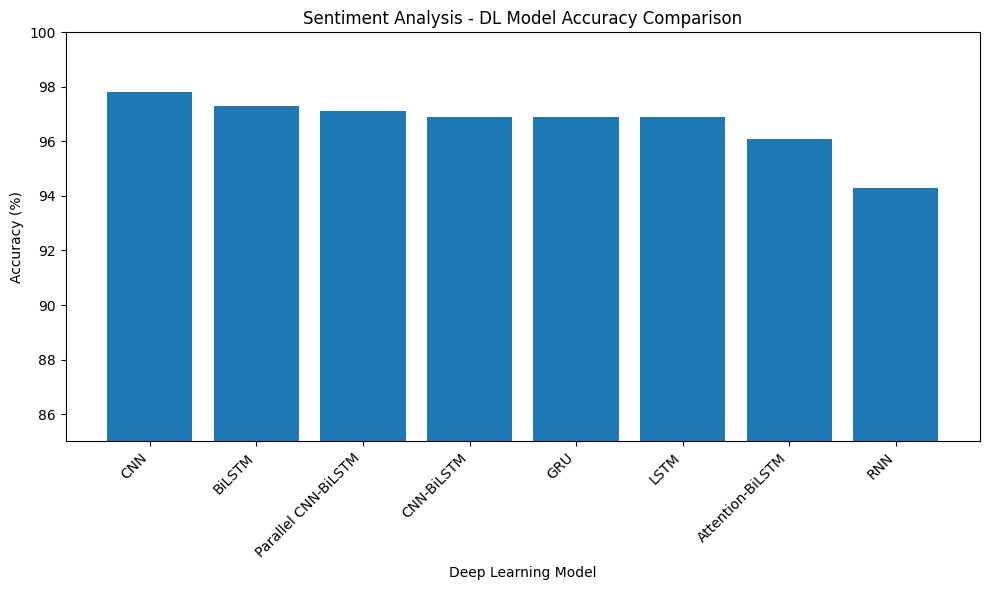

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    dl_results_df['Model'],
    dl_results_df['Accuracy'] * 100
)

plt.xlabel('Deep Learning Model')
plt.ylabel('Accuracy (%)')
plt.title('Sentiment Analysis - DL Model Accuracy Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(85, 100)

plt.tight_layout()
plt.show()

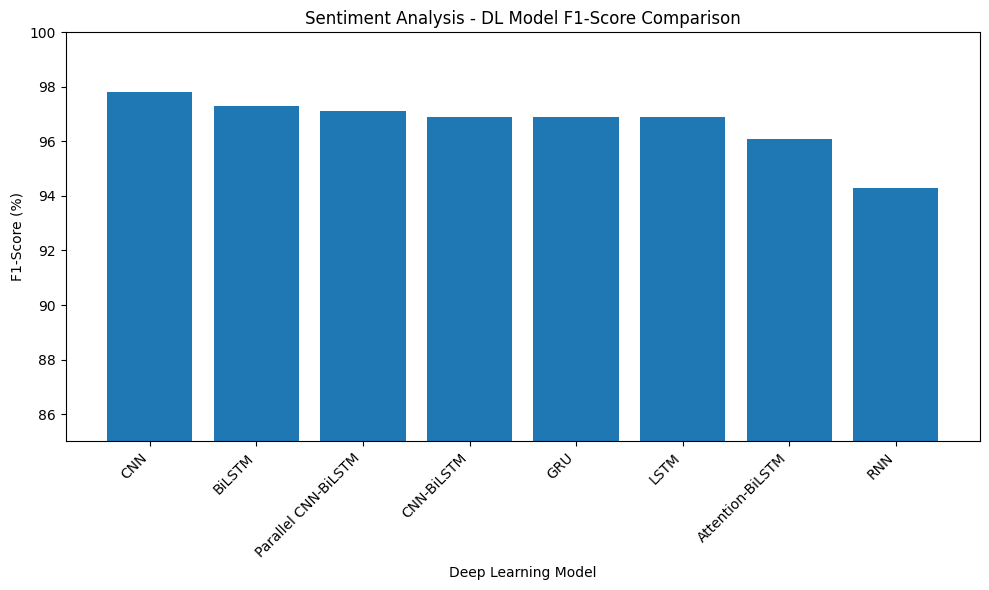

In [61]:
plt.figure(figsize=(10, 6))

plt.bar(
    dl_results_df['Model'],
    dl_results_df['F1-Score'] * 100
)

plt.xlabel('Deep Learning Model')
plt.ylabel('F1-Score (%)')
plt.title('Sentiment Analysis - DL Model F1-Score Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(85, 100)

plt.tight_layout()
plt.show()

In [62]:
# Step 43: Save DL comparison results

dl_results_df.to_csv(
    'sentiment_dl_model_comparison.csv',
    index=False
)

print("Sentiment DL comparison saved successfully!")

Sentiment DL comparison saved successfully!


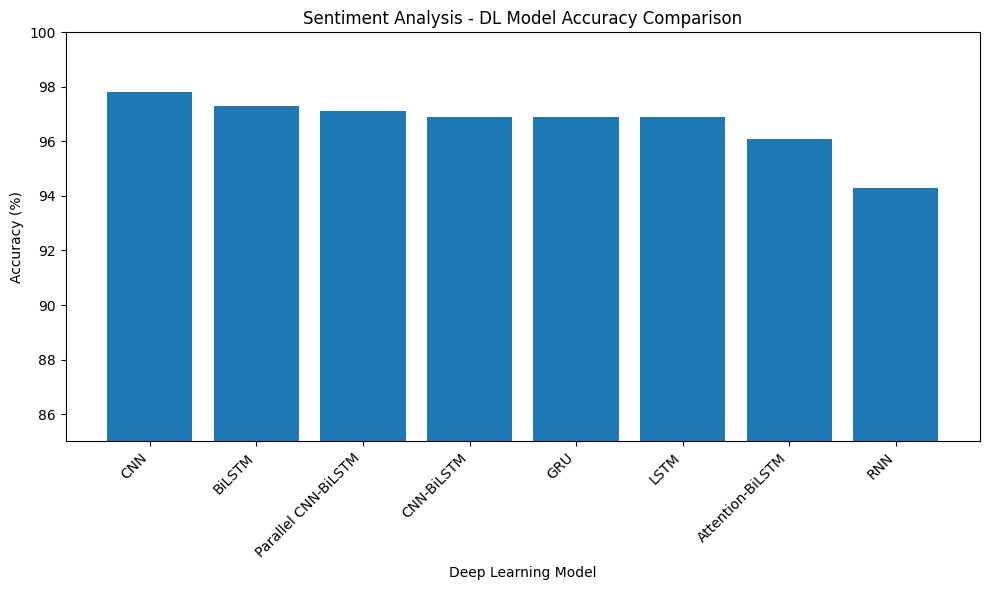

In [63]:
# Save Accuracy graph

plt.figure(figsize=(10, 6))

plt.bar(
    dl_results_df['Model'],
    dl_results_df['Accuracy'] * 100
)

plt.xlabel('Deep Learning Model')
plt.ylabel('Accuracy (%)')
plt.title('Sentiment Analysis - DL Model Accuracy Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(85, 100)

plt.tight_layout()

plt.savefig(
    'sentiment_dl_accuracy_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

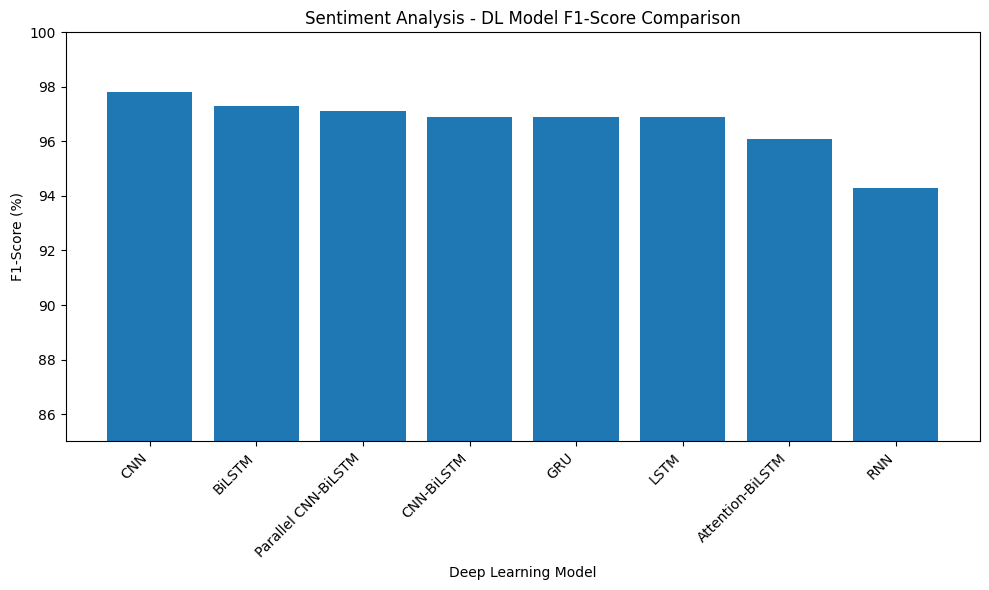

In [64]:
# Save F1-score graph

plt.figure(figsize=(10, 6))

plt.bar(
    dl_results_df['Model'],
    dl_results_df['F1-Score'] * 100
)

plt.xlabel('Deep Learning Model')
plt.ylabel('F1-Score (%)')
plt.title('Sentiment Analysis - DL Model F1-Score Comparison')

plt.xticks(rotation=45, ha='right')
plt.ylim(85, 100)

plt.tight_layout()

plt.savefig(
    'sentiment_dl_f1_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [65]:
# Step 45: Save best Sentiment DL model

import joblib

# Save CNN model
cnn_model.save('sentiment_cnn.keras')

# Save tokenizer
joblib.dump(
    tokenizer,
    'sentiment_dl_tokenizer.pkl'
)

# Save label encoder
joblib.dump(
    label_encoder,
    'sentiment_dl_label_encoder.pkl'
)

print("Best Sentiment DL model saved successfully!")

Best Sentiment DL model saved successfully!


In [66]:
from google.colab import files

files_to_download = [
    'sentiment_dl_model_comparison.csv',
    'sentiment_dl_accuracy_comparison.png',
    'sentiment_dl_f1_comparison.png',
    'sentiment_cnn.keras',
    'sentiment_dl_tokenizer.pkl',
    'sentiment_dl_label_encoder.pkl'
]

for file in files_to_download:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>